In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lmt_simulation as sim

plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

## Plot 1: Discard rate vs initial excited fraction

Sweep $|c_1|^2$ from 0 to 1. For each value, run 2000 MC trials of `make_atom_states -> do_clearout`.
The empirical discard rate should overlap with the analytical line $1 - |c_1|^2$.

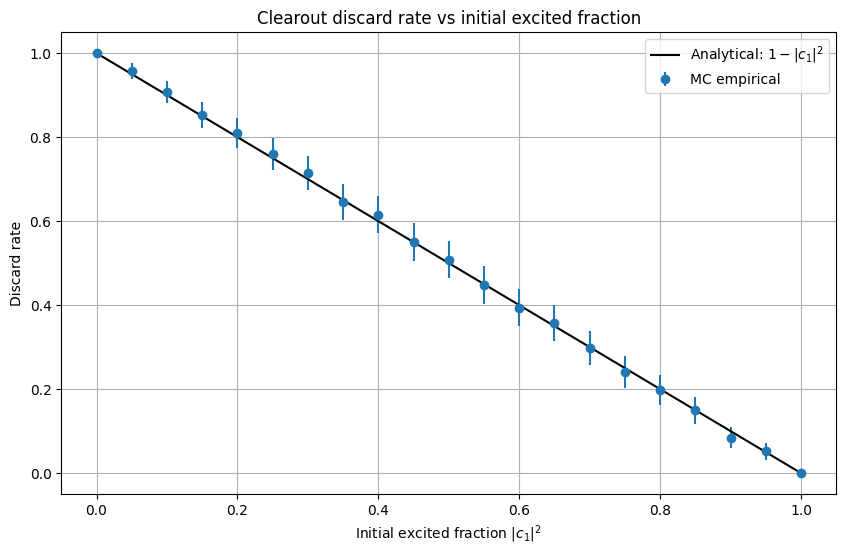

In [2]:
excited_fractions = np.linspace(0, 1, 21)
n_trials = 2000
discard_rates = []
errors = []

for i, ef in enumerate(excited_fractions):
    c1 = np.sqrt(ef)
    c0 = np.sqrt(1 - ef) if ef < 1 else 0.0
    
    n_discards = 0
    for trial in range(n_trials):
        rng = np.random.default_rng(i * n_trials + trial)
        m, pos, vel, amp, isg = sim.make_atom_states(c0=c0, c1=c1)
        omega = 2 * np.pi * sim.TRANSITION_FREQUENCY
        squiggly = sim.transform_state_vector(m, amp, isg, omega_laser=omega, t=0, z=0, vz=0, inverse=False)
        result = sim.do_clearout(m, squiggly, isg, pos, vel, rng=rng)
        if result is None:
            n_discards += 1
    
    rate = n_discards / n_trials
    discard_rates.append(rate)
    errors.append(4.0 * np.sqrt(rate * (1 - rate) / n_trials))

plt.figure()
plt.errorbar(excited_fractions, discard_rates, yerr=errors, fmt='o', label='MC empirical')
plt.plot(excited_fractions, 1 - excited_fractions, 'k-', label='Analytical: $1 - |c_1|^2$')
plt.xlabel('Initial excited fraction $|c_1|^2$')
plt.ylabel('Discard rate')
plt.title('Clearout discard rate vs initial excited fraction')
plt.legend()
plt.grid(True)
plt.show()

## Plot 2: Mach-Zehnder with clearout

Standard pi/2 - pi - pi/2 MZ phase scan with `do_clearout` inserted between the pi and final pi/2 pulses.

Expectations:
- P_discarded ~ 0.5 (atoms in ground after the pi pulse are blown away regardless of phi)
- After clearout only excited-state atoms remain; for a resonant pi pulse these are concentrated in a single momentum branch, so the final pi/2 pulse produces no interference fringe — P_ground and P_excited are flat at ~0.25 each (0.5 of the surviving 0.5 population, split equally by the final pi/2).

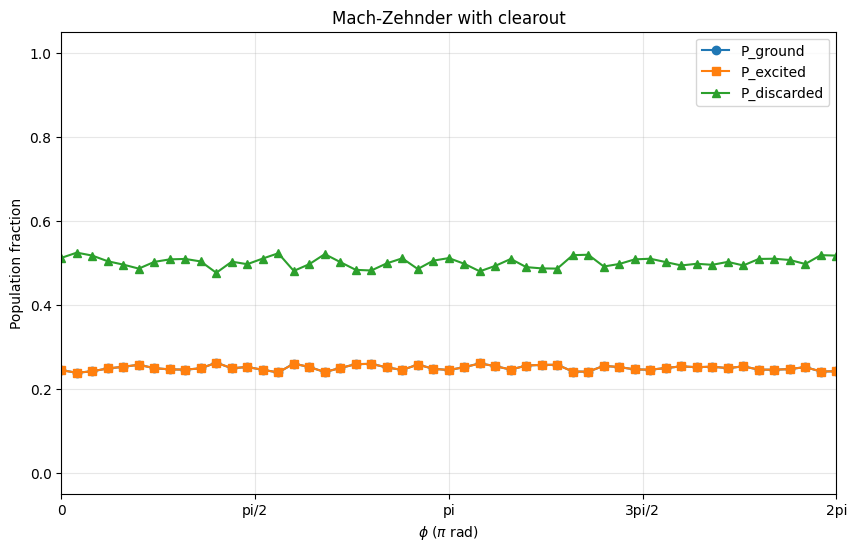

In [3]:
T_FREE = 200e-6
DETUNING_HZ = sim.RECOIL_FREQUENCY_HZ
OMEGA_LASER = 2 * np.pi * (sim.TRANSITION_FREQUENCY + DETUNING_HZ)

def mz_sequence_with_clearout(phi, rng):
    """Run a pi/2 - pi - clearout - pi/2 MZ sequence. Returns state tuple or None."""
    m, pos, vel, amp, isg = sim.make_atom_states(c0=1, c1=0)
    current_time = 0.0
    vz = 0.0
    
    squiggly = sim.transform_state_vector(m, amp, isg, omega_laser=OMEGA_LASER, t=current_time, z=0.0, vz=vz, inverse=False)
    
    m, squiggly, isg, pos, vel = sim.pulse_interaction_in_borde_representation(
        m, squiggly, isg, pos, vel,
        pulse_detuning=DETUNING_HZ, t_pulse=sim.T_PI / 2, pulse_rabi_freq=sim.RABI_FREQ,
        pulse_phase=0.0, k_sign=+1, k_wavevector=sim.K_WAVEVECTOR, vz=vz,
    )
    current_time += sim.T_PI / 2
    
    m, squiggly, isg, pos, vel = sim.propagate_states_in_borde_representation(
        m, squiggly, isg, pos, vel,
        time_of_propegation=T_FREE, omega_laser=OMEGA_LASER, vz=vz, k_sign=+1, k_wavevector=sim.K_WAVEVECTOR,
    )
    current_time += T_FREE
    
    m, squiggly, isg, pos, vel = sim.pulse_interaction_in_borde_representation(
        m, squiggly, isg, pos, vel,
        pulse_detuning=DETUNING_HZ, t_pulse=sim.T_PI, pulse_rabi_freq=sim.RABI_FREQ,
        pulse_phase=phi, k_sign=+1, k_wavevector=sim.K_WAVEVECTOR, vz=vz,
    )
    current_time += sim.T_PI
    
    result = sim.do_clearout(m, squiggly, isg, pos, vel, rng=rng)
    if result is None:
        return None
    m, squiggly, isg, pos, vel = result
    
    m, squiggly, isg, pos, vel = sim.propagate_states_in_borde_representation(
        m, squiggly, isg, pos, vel,
        time_of_propegation=T_FREE, omega_laser=OMEGA_LASER, vz=vz, k_sign=+1, k_wavevector=sim.K_WAVEVECTOR,
    )
    current_time += T_FREE
    
    m, squiggly, isg, pos, vel = sim.pulse_interaction_in_borde_representation(
        m, squiggly, isg, pos, vel,
        pulse_detuning=DETUNING_HZ, t_pulse=sim.T_PI / 2, pulse_rabi_freq=sim.RABI_FREQ,
        pulse_phase=4 * phi, k_sign=+1, k_wavevector=sim.K_WAVEVECTOR, vz=vz,
    )
    current_time += sim.T_PI / 2
    
    amp_final = sim.transform_state_vector(m, squiggly, isg, omega_laser=OMEGA_LASER, t=current_time, z=0.0, vz=vz, inverse=True)
    return m, amp_final, isg, pos, vel


phi_values = np.linspace(0, 2 * np.pi, 51)
n_trials = 2000

p_ground = np.empty_like(phi_values)
p_excited = np.empty_like(phi_values)
p_discarded = np.empty_like(phi_values)

for i, phi in enumerate(phi_values):
    rng = np.random.default_rng(1000 + i)
    pg, pe, pd = sim.run_clearout_trials(
        lambda rng: mz_sequence_with_clearout(phi, rng), n_trials=n_trials, rng=rng
    )
    p_ground[i] = pg
    p_excited[i] = pe
    p_discarded[i] = pd

plt.figure()
plt.plot(phi_values / np.pi, p_ground, 'o-', label='P_ground')
plt.plot(phi_values / np.pi, p_excited, 's-', label='P_excited')
plt.plot(phi_values / np.pi, p_discarded, '^-', label='P_discarded')
plt.xlabel(r'$\phi$ ($\pi$ rad)')
plt.ylabel('Population fraction')
plt.title('Mach-Zehnder with clearout')
plt.xticks([0, 0.5, 1, 1.5, 2], ['0', 'pi/2', 'pi', '3pi/2', '2pi'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 2)
plt.ylim(-0.05, 1.05)
plt.show()